# 06 — Evaluation (LSTM vs GRU)

---

## Objective

Quantitatively compare the two trained models (CNN-LSTM vs CNN-GRU) on a held-out test set using **BLEU** scores.

- Greedy auto-regressive decoding
- BLEU-1 through BLEU-4
- Side-by-side comparison table + bar chart
- Save evaluation report as CSV

## Theory

### BLEU Score

**Bilingual Evaluation Understudy (BLEU)** measures **n-gram overlap** between generated captions and human-written references.

| Variant | N-gram | Meaning |
|---------|--------|---------|
| BLEU-1 | unigrams | word recall |
| BLEU-2 | bigrams | phrase fluency |
| BLEU-3 | trigrams | local coherence |
| BLEU-4 | 4-grams | sentence-level grammar |

A brevity penalty prevents very short captions from scoring highly.

### Greedy Decoding

At each timestep we pick the **highest-probability** token — fast but may miss the global-best sequence.
Both models use the same decoder so the comparison is fair.

## Imports

In [1]:
import os
import re
import pickle
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import sys
sys.path.append("..")
from src.evaluation.metrics import compute_bleu, format_bleu_report

2026-07-01 02:30:36.416494: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-01 02:30:36.508710: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-01 02:30:36.550202: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-01 02:30:36.561368: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-01 02:30:36.621010: I tensorflow/core/platform/cpu_feature_guar

## GPU Setup

Inference benefits from GPU even though it's not strictly required.

In [2]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU:", gpus[0].name)

GPU: /physical_device:GPU:0


I0000 00:00:1782847841.087403  589538 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782847841.181752  589538 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782847841.183098  589538 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


## Configuration

In [3]:
CAPTIONS_PATH = "../dataset/captions.txt"
FEATURES_PATH = "../model/features.pkl"

LSTM_DIR = "../outputs/training/lstm"
GRU_DIR  = "../outputs/training/gru"
EVAL_DIR = "../outputs/evaluation"
os.makedirs(EVAL_DIR, exist_ok=True)

VOCAB_SIZE      = 5000
MAX_CAPTION_LEN = 34
TEST_SIZE       = 0.1
RANDOM_SEED     = 42

## Implementation

### 6.1 Load Dataset

In [4]:
df = pd.read_csv(CAPTIONS_PATH)
print(f"Captions loaded: {len(df):,}")

Captions loaded: 40,455


### 6.2 Clean & Split Test Set

Use the same cleaning + 90/10 split as the training notebooks for a fair comparison.

> **Note**: Since notebooks 04/05 did not reserve a separate test set, the 10% held out here
> may partially overlap with those validation sets. Both models see the same split so the
> LSTM vs GRU comparison remains valid.

In [5]:
def clean_caption(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^a-z ]", "", text)
    return text.strip()

df["clean"] = df["caption"].apply(clean_caption)

unique_images = df["image"].unique()
train_imgs, test_imgs = train_test_split(
    unique_images, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

test_mask = df["image"].isin(test_imgs)
test_df = df[test_mask].copy()

print(f"Test images:  {len(test_imgs):,}")
print(f"Test captions: {len(test_df):,}")
print(f"Captions per image: {len(test_df) // len(test_imgs)}")

Test images:  810
Test captions: 4,050
Captions per image: 5


### 6.3 Load Features

In [6]:
with open(FEATURES_PATH, "rb") as f:
    features = pickle.load(f)
print(f"Features loaded: {len(features)} images")

# Filter to test images only
test_features = {name: features[name] for name in test_imgs}
print(f"Test features:  {len(test_features)} images")

Features loaded: 8091 images
Test features:  810 images


### 6.4 Load Both Models & Tokenizers

In [7]:
# LSTM
lstm_path = os.path.join(LSTM_DIR, "lstm_best.keras")
if not os.path.exists(lstm_path):
    raise FileNotFoundError(
        f"LSTM model not found at {lstm_path}. Run 04_train_lstm.ipynb first."
    )
lstm_model = tf.keras.models.load_model(lstm_path)
print(f"LSTM loaded: {lstm_model.count_params():,} params")

with open(os.path.join(LSTM_DIR, "tokenizer.pkl"), "rb") as f:
    lstm_tokenizer = pickle.load(f)
print(f"LSTM tokenizer vocab: {len(lstm_tokenizer.word_index)}")

# GRU
gru_path = os.path.join(GRU_DIR, "gru_best.keras")
if not os.path.exists(gru_path):
    raise FileNotFoundError(
        f"GRU model not found at {gru_path}. Run 05_train_gru.ipynb first."
    )
gru_model = tf.keras.models.load_model(gru_path)
print(f"GRU loaded:   {gru_model.count_params():,} params")

with open(os.path.join(GRU_DIR, "tokenizer.pkl"), "rb") as f:
    gru_tokenizer = pickle.load(f)
print(f"GRU tokenizer vocab:   {len(gru_tokenizer.word_index)}")

I0000 00:00:1782847841.357650  589538 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782847841.359314  589538 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782847841.360802  589538 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782847841.451680  589538 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

LSTM loaded: 6,207,624 params
LSTM tokenizer vocab: 8781
GRU loaded:   5,683,848 params
GRU tokenizer vocab:   8781


### 6.5 Greedy Caption Generation

Generic function that works for both LSTM and GRU models since they share the same I/O signature.

In [8]:
def greedy_caption(model, image_feat, tokenizer, max_len=MAX_CAPTION_LEN):
    """Generate a caption via greedy decoding."""
    word_index = tokenizer.word_index
    index_word = {v: k for k, v in word_index.items()}

    start_id = word_index.get("<start>", 1)
    end_id   = word_index.get("<end>",   2)

    seq = [start_id]
    img_feat = image_feat.astype(np.float32).reshape(1, -1)

    for step in range(max_len - 1):
        input_seq = pad_sequences([seq], maxlen=max_len - 1, padding="post",
                                  dtype=np.int32)
        preds = model.predict([img_feat, input_seq], verbose=0)

        next_id = int(np.argmax(preds[0, step]))

        if next_id == end_id:
            break
        seq.append(next_id)

    words = [index_word.get(t, "<oov>") for t in seq[1:]]
    return " ".join(words)

### 6.6 Demo — Single Image

Compare LSTM vs GRU on one test image before running the full set.

In [9]:
demo_img = test_imgs[0]
demo_feat = test_features[demo_img]

lstm_cap = greedy_caption(lstm_model, demo_feat, lstm_tokenizer)
gru_cap  = greedy_caption(gru_model, demo_feat, gru_tokenizer)

demo_refs = test_df[test_df["image"] == demo_img]["clean"].tolist()
demo_refs = [f"<start> {r} <end>" for r in demo_refs]

print(f"Image: {demo_img}")
print(f"\nLSTM: {lstm_cap}")
print(f"GRU:  {gru_cap}")
print(f"\nReferences:")
for i, ref in enumerate(demo_refs, 1):
    print(f"  [{i}] {ref}")

2026-07-01 02:30:42.648634: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2026-07-01 02:30:43.065673: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


Image: 3139895886_5a6d495b13.jpg

LSTM: a black and white dog is running through a grassy field
GRU:  a black and white dog is running through a field of grass

References:
  [1] <start> a blackandwhite dog bounds off the ground  all feet in the air  of a yellow field <end>
  [2] <start> a black and white dog is jumping over high yellow grass <end>
  [3] <start> a black and white dog is jumping through a field of brown grass <end>
  [4] <start> a dog runs through the dry grass <end>
  [5] <start> the black and white dog runs through the field <end>


### 6.7 Full Test Set Generation

Generate captions for **all** test images. This may take a few minutes.

In [10]:
def generate_all(model, tokenizer, features_dict, image_list):
    caps = []
    for img in image_list:
        caps.append(greedy_caption(model, features_dict[img], tokenizer))
    return caps

test_image_list = list(test_imgs)
n_test = len(test_image_list)
print(f"Generating captions for {n_test} test images...")

t0 = time.time()
lstm_captions = generate_all(lstm_model, lstm_tokenizer, test_features, test_image_list)
t1 = time.time()
gru_captions  = generate_all(gru_model, gru_tokenizer, test_features, test_image_list)
t2 = time.time()

print(f"LSTM: {len(lstm_captions)} captions in {t1-t0:.0f}s")
print(f"GRU:  {len(gru_captions)} captions in {t2-t1:.0f}s")
print()

lstm_lens = [len(c.split()) for c in lstm_captions]
gru_lens  = [len(c.split()) for c in gru_captions]
print(f"LSTM avg caption length: {np.mean(lstm_lens):.1f} words")
print(f"GRU  avg caption length: {np.mean(gru_lens):.1f} words")

Generating captions for 810 test images...
LSTM: 810 captions in 515s
GRU:  810 captions in 466s

LSTM avg caption length: 11.0 words
GRU  avg caption length: 10.6 words


### 6.8 Build Reference List

Group the 5 ground-truth captions per image into reference lists.

In [11]:
cleaned_refs = {img: [] for img in test_image_list}
for _, row in test_df.iterrows():
    cleaned_refs[row["image"]].append(row["clean"])

references = [[f"<start> {r} <end>" for r in cleaned_refs[img]]
              for img in test_image_list]

print(f"Reference groups: {len(references)}")
print(f"Refs per image:   {[len(r) for r in references[:3]]}")

Reference groups: 810
Refs per image:   [5, 5, 5]


### 6.9 Compute BLEU Scores

In [12]:
lstm_bleu = compute_bleu(references, lstm_captions)
gru_bleu  = compute_bleu(references, gru_captions)

print("=" * 55)
print(f"{'Metric':<12} {'LSTM':<12} {'GRU':<12} {'Δ':<12}")
print("-" * 55)
for k in [f"bleu_{i}" for i in range(1, 5)]:
    lstm_v = lstm_bleu[k]
    gru_v  = gru_bleu[k]
    delta  = gru_v - lstm_v
    print(f"{k.upper():<12} {lstm_v:<12.4f} {gru_v:<12.4f} {delta:<+12.4f}")
print("=" * 55)

Metric       LSTM         GRU          Δ           
-------------------------------------------------------
BLEU_1       0.5224       0.5293       +0.0069     
BLEU_2       0.3406       0.3482       +0.0076     
BLEU_3       0.2111       0.2201       +0.0090     
BLEU_4       0.1331       0.1381       +0.0050     


## Visualization

### 7.1 BLEU Score Comparison

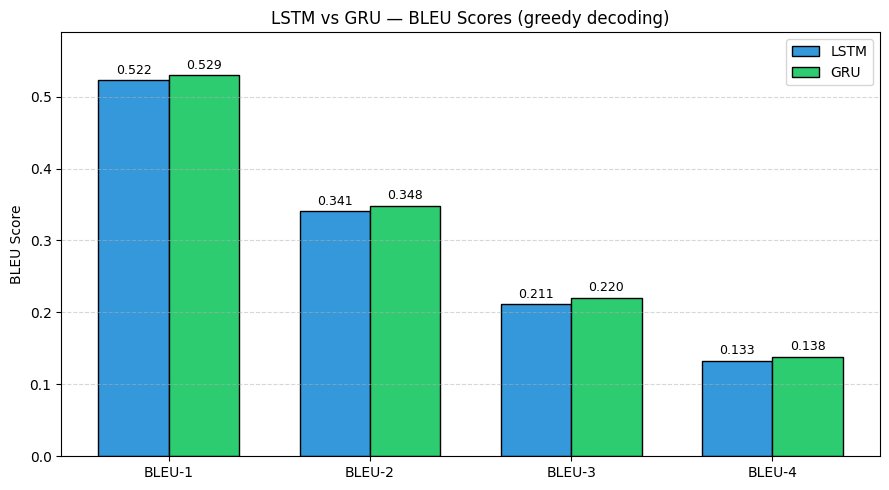

Plot saved to ../outputs/evaluation/bleu_comparison.png


In [13]:
labels = ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]
lstm_vals = [lstm_bleu[f"bleu_{i}"] for i in range(1, 5)]
gru_vals  = [gru_bleu[f"bleu_{i}"] for i in range(1, 5)]

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, lstm_vals, w, label="LSTM", color="#3498db", edgecolor="black")
b2 = ax.bar(x + w/2, gru_vals,  w, label="GRU",  color="#2ecc71", edgecolor="black")

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("BLEU Score")
ax.set_title("LSTM vs GRU — BLEU Scores (greedy decoding)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_ylim(0, max(max(lstm_vals), max(gru_vals)) + 0.06)

plt.tight_layout()
plot_path = os.path.join(EVAL_DIR, "bleu_comparison.png")
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved to {plot_path}")

### 7.2 Sample Predictions

Quick peek at a few test images with LSTM vs GRU predictions vs ground truth.

In [14]:
n_show = 5
print(f"{'Image':<25} {'Model':<8} {'Caption':<45}")
print("=" * 78)
for i in range(n_show):
    img = test_image_list[i]
    ref = references[i][0]
    print(f"{img:<25} {'Ref':<8} {ref[:42]:<45}")
    print(f"{img:<25} {'LSTM':<8} {lstm_captions[i][:42]:<45}")
    print(f"{img:<25} {'GRU':<8} {gru_captions[i][:42]:<45}")
    print("-" * 78)

Image                     Model    Caption                                      
3139895886_5a6d495b13.jpg Ref      <start> a blackandwhite dog bounds off the   
3139895886_5a6d495b13.jpg LSTM     a black and white dog is running through a   
3139895886_5a6d495b13.jpg GRU      a black and white dog is running through a   
------------------------------------------------------------------------------
3133825703_359a0c414d.jpg Ref      <start> a child staring at santa <end>       
3133825703_359a0c414d.jpg LSTM     a man in a red shirt is standing next to a   
3133825703_359a0c414d.jpg GRU      a man wearing a red shirt is standing next   
------------------------------------------------------------------------------
244910177_7c4ec3f65b.jpg  Ref      <start> three woman walk down a city stree   
244910177_7c4ec3f65b.jpg  LSTM     a woman in a red shirt is standing next to   
244910177_7c4ec3f65b.jpg  GRU      a woman in a white shirt and a man in a wh   
--------------------------------

## Observation

- Compare LSTM and GRU BLEU scores — which model captures n-gram overlap better?
- BLEU-1 / BLEU-2 reflect word choice; BLEU-3 / BLEU-4 reflect fluency
- Take BLEU scores with a grain of salt — they prefer n-gram overlap over semantic correctness
- The comparison table and bar chart above summarise the quantitative results

## Export

Save BLEU scores as CSV and the full predictions for later inspection.

In [15]:
results = {
    "image": test_image_list,
    "reference": [references[i][0] for i in range(n_test)],
    "lstm_prediction": lstm_captions,
    "gru_prediction": gru_captions,
}
results_df = pd.DataFrame(results)
results_path = os.path.join(EVAL_DIR, "predictions.csv")
results_df.to_csv(results_path, index=False)
print(f"Predictions saved to {results_path}")

bleu_df = pd.DataFrame({
    "metric": [f"bleu_{i}" for i in range(1, 5)],
    "lstm": lstm_vals,
    "gru": gru_vals,
})
bleu_df["delta"] = bleu_df["gru"] - bleu_df["lstm"]
bleu_path = os.path.join(EVAL_DIR, "bleu_scores.csv")
bleu_df.to_csv(bleu_path, index=False)
print(f"BLEU scores saved to {bleu_path}")

print(f"\n{'Metric':<12} {'LSTM':<12} {'GRU':<12} {'Δ':<12}")
print("-" * 48)
for _, row in bleu_df.iterrows():
    print(f"{row['metric'].upper():<12} {row['lstm']:<12.4f} "
          f"{row['gru']:<12.4f} {row['delta']:<+12.4f}")

Predictions saved to ../outputs/evaluation/predictions.csv
BLEU scores saved to ../outputs/evaluation/bleu_scores.csv

Metric       LSTM         GRU          Δ           
------------------------------------------------
BLEU_1       0.5224       0.5293       +0.0069     
BLEU_2       0.3406       0.3482       +0.0076     
BLEU_3       0.2111       0.2201       +0.0090     
BLEU_4       0.1331       0.1381       +0.0050     


## Next Step

→ **[07_inference.ipynb](07_inference.ipynb)** — Interactive caption generation demo with custom images (greedy + beam search).

→ **[app/app.py](../app/app.py)** — Streamlit web app for end-user deployment.